In [6]:
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

### Figure 6A

In [7]:
#### Import the HCC spot prediction probablities
df_pred_cyt_spot=pd.read_csv("/data/kumarr17/figures_to_upload/supplementray_table/pred_cyt_on_spatial_spot_fixed_features.csv",index_col='Unnamed: 0')
df_spatial=pd.read_csv("/data/kumarr17/figures_to_upload/supplementray_table/smoothed_expression_radius2.csv")

In [8]:
df_spatial_v1=df_spatial[['spot_id','sample','response']]
df_spatial_v2=df_spatial_v1.set_index('spot_id')
df_pred_cyt_spot_response_merge=pd.merge(df_pred_cyt_spot,df_spatial_v2,left_index=True,right_index=True)
df=df_pred_cyt_spot_response_merge

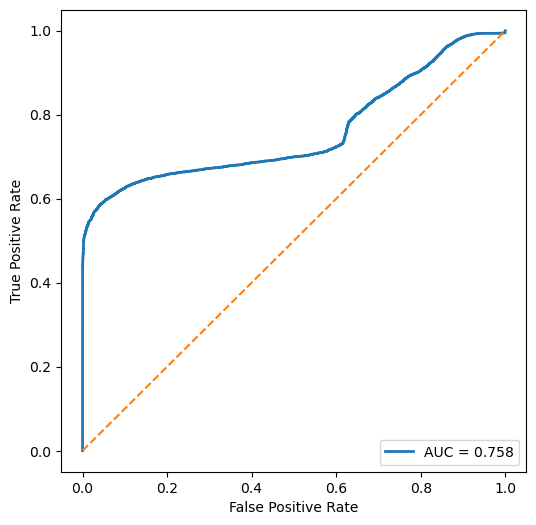

In [9]:
df = df.copy()
df['spot_id'] = df.index

cytokine_cols = [c for c in df.columns if c not in ['spot_id', 'sample', 'response', 'region']]

X = df[cytokine_cols]
y = df['response'].map({'Responder': 1, 'NonResponder': 0})
groups = df['sample'].values

# choose number of folds
n_groups = df['sample'].nunique()
n_splits = min(7, n_groups)

gkf = GroupKFold(n_splits=n_splits)

spot_pred_list = []
sample_results = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):
    test_samples = sorted(df.iloc[test_idx]['sample'].unique())

    X_train = X.iloc[train_idx]
    X_test  = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test  = y.iloc[test_idx]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    model = LogisticRegression(max_iter=1000, class_weight='balanced')
    model.fit(X_train_scaled, y_train)

    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    tmp = df.iloc[test_idx][['spot_id', 'sample', 'response']].copy()
    tmp['true_label'] = y_test.values
    tmp['fold'] = fold
    tmp['prob_responder'] = y_prob
    tmp['prob_nonresponder'] = 1 - y_prob
    spot_pred_list.append(tmp)

    # summarize each held-out sample in this fold
    for s in test_samples:
        s_idx = tmp['sample'] == s
        y_prob_s = tmp.loc[s_idx, 'prob_responder'].values
        y_true_s = tmp.loc[s_idx, 'true_label'].iloc[0]

        sample_results.append({
            'fold': fold,
            'sample': s,
            'true_label': int(y_true_s),
            'pred_score_mean': float(np.mean(y_prob_s)),
            'pred_score_median': float(np.median(y_prob_s)),
            'n_spots': int(s_idx.sum())
        })

spot_pred_df = pd.concat(spot_pred_list, axis=0).reset_index(drop=True)
sample_results_df = pd.DataFrame(sample_results)

# -------------------------
# AUC calculations
# -------------------------
# ============================================================
# Calculate spot-level AUC
# ============================================================

spot_auc = roc_auc_score(
    spot_pred_df['true_label'],
    spot_pred_df['prob_responder']
)

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(
    spot_pred_df['true_label'],
    spot_pred_df['prob_responder']
)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {spot_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")

# Save as SVG
#plt.savefig(
#    "/data/kumarr17/figures_to_upload/Figure5/spot_level_ROC_curve_hcc.svg",
#    format="svg",
#    bbox_inches="tight"
#)

plt.show()
